Descriptive Analysis

Importing the required libraries and merging the files

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

path = "C:/Users/sandy/output/"
discharge = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv")
cardiac = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv")
responsiveness = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")
demography = pd.read_csv(path + "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")

df = discharge.merge(cardiac, on="inpatient_number").merge(responsiveness, on="inpatient_number")
df.shape  # should be (2008, 39)

(2008, 39)

In [3]:
import os
print(os.getcwd())        # see where Jupyter is currently looking
os.listdir() 

C:\Users\sandy


['.anaconda',
 '.conda',
 '.continuum',
 '.gitconfig',
 '.ipynb_checkpoints',
 '.ipython',
 '.jupyter',
 '.lesshst',
 '.matplotlib',
 '.ms-ad',
 '3D Objects',
 'anaconda3',
 'anaconda_projects',
 'ansel',
 'AnypointStudio',
 'AppData',
 'Application Data',
 'cleaned.csv',
 'Contacts',
 'Cookies',
 'Desktop',
 'Documents',
 'Downloads',
 'Favorites',
 'IntelGraphicsProfiles',
 'Links',
 'Local Settings',
 'MicrosoftEdgeBackups',
 'Music',
 'My Documents',
 'NetHood',
 'NTUSER.DAT',
 'ntuser.dat.LOG1',
 'ntuser.dat.LOG2',
 'NTUSER.DAT{ee5242f8-9188-11f1-9d69-ba4291ed6c25}.TM.blf',
 'NTUSER.DAT{ee5242f8-9188-11f1-9d69-ba4291ed6c25}.TMContainer00000000000000000001.regtrans-ms',
 'NTUSER.DAT{ee5242f8-9188-11f1-9d69-ba4291ed6c25}.TMContainer00000000000000000002.regtrans-ms',
 'ntuser.ini',
 'OneDrive',
 'output',
 'Pictures',
 'Postman',
 'Presentation practice.ipynb',
 'PrintHood',
 'Recent',
 'SandhyaKammarinagaDA211_code_pythonhackathon.ipynb',
 'Saved Games',
 'Searches',
 'SendTo',
 'St

1. Data quality / missingness

Q: Which columns have the most missing data, and should they be dropped or imputed?

In [8]:
missing = df.isna().mean().sort_values(ascending=False) * 100
missing[missing > 0]

respiratory_support                               97.908367
time_of_death__days_from_admission                97.808765
tricuspid_valve_return_pressure                   90.936255
ea                                                80.428287
mitral_valve_ams                                  72.609562
lvef                                              68.376494
tricuspid_valve_return_velocity                   60.657371
time_to_emergency_department_within_6_months      55.328685
readmission_time_days_from_admission              55.129482
mitral_valve_ems                                  51.195219
left_ventricular_end_diastolic_diameter_lv        34.711155
return_to_emergency_department_within_6_months     0.049801
dtype: float64

2. Are there duplicate patients or inconsistent visit_times entries?

In [9]:
df["inpatient_number"].duplicated().sum()
df["visit_times"].value_counts()

visit_times
1    1860
2     120
3      20
4       6
5       2
Name: count, dtype: int64

2. Showing Admission patterns
 Q: How are patients distributed across admission ward, admission way (emergency vs non-emergency), and discharge department?

In [10]:
df["admission_ward"].value_counts()
df["admission_way"].value_counts(normalize=True) * 100
df["discharge_department"].value_counts()

discharge_department
Cardiology     1703
GeneralWard     241
Others           52
ICU              12
Name: count, dtype: int64

Q. What's the distribution of length of stay (dischargeday)? Any outliers?

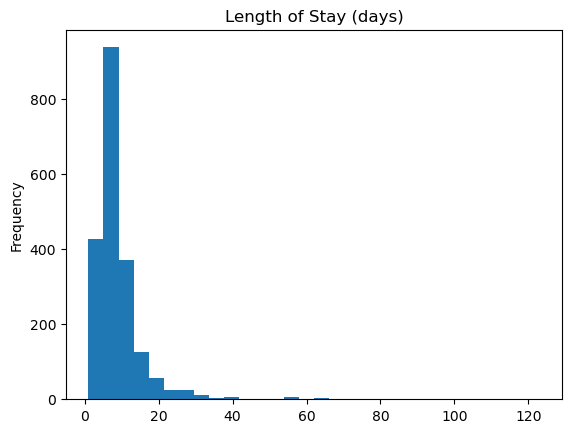

In [11]:
df["dischargeday"].describe()
df["dischargeday"].plot(kind="hist", bins=30, title="Length of Stay (days)")
plt.show()

Q. Has admission volume trended over time? (uses admission_date)

C:\Users\sandy\AppData\Local\Temp\ipykernel_26560\2893101521.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.set_index("admission_date").resample("M").size().plot(title="Admissions per Month")


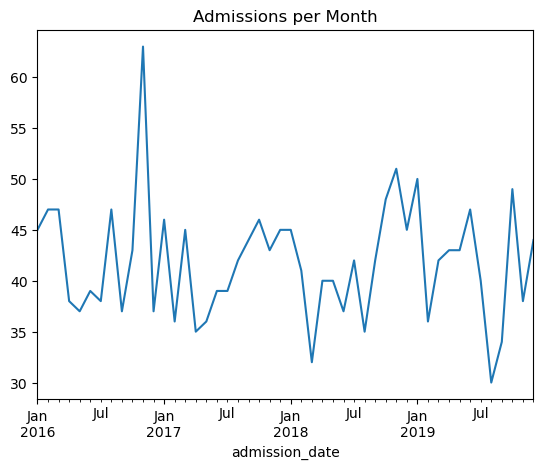

In [12]:
df["admission_date"] = pd.to_datetime(df["admission_date"])
df.set_index("admission_date").resample("M").size().plot(title="Admissions per Month")
plt.show()

    Cardiac severity profile
Q: What's the distribution of NYHA class and Killip grade — how sick is this cohort on admission?

In [13]:
df["nyha_cardiac_function_classification"].value_counts().sort_index()
df["killip_grade"].value_counts().sort_index()

killip_grade
1     527
2    1029
3     392
4      60
Name: count, dtype: int64

Q: What proportion have comorbid MI, congestive heart failure, or peripheral vascular disease?

In [14]:
df[["myocardial_infarction","congestive_heart_failure","peripheral_vascular_disease"]].mean() * 100

myocardial_infarction           7.121514
congestive_heart_failure       93.227092
peripheral_vascular_disease     5.029880
dtype: float64

Q: How does LVEF (ejection fraction) vary by type of heart failure (Left/Right/Both)?

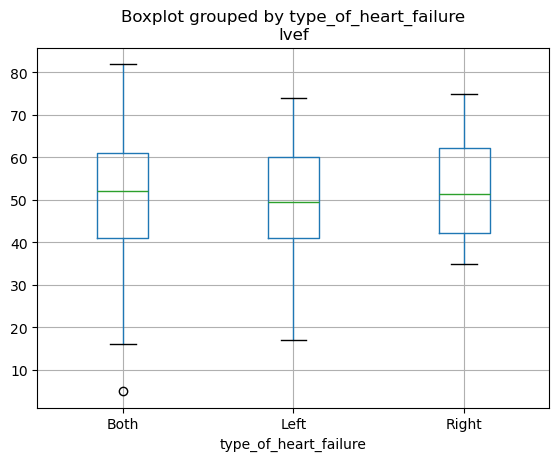

In [15]:
df.groupby("type_of_heart_failure")["lvef"].describe()
df.boxplot(column="lvef", by="type_of_heart_failure")
plt.show()

4. Consciousness / GCS

Q: What's the distribution of GCS scores, and how many patients are fully alert (GCS 15) vs impaired?

In [16]:
df["gcs"].value_counts().sort_index()
df["consciousness"].value_counts()

consciousness
Clear                  1974
Responsive To Sound      19
Nonresponsive            11
Responsive To Pain        4
Name: count, dtype: int64

5. Outcomes

Q: What are the overall in-hospital, 28-day, 3-month, and 6-month mortality/readmission rates?

In [17]:
outcome_cols = ["death_within_28_days","death_within_3_months","death_within_6_months",
                 "re_admission_within_28_days","re_admission_within_3_months","re_admission_within_6_months"]
df[outcome_cols].mean() * 100

death_within_28_days             1.842629
death_within_3_months            2.091633
death_within_6_months            2.838645
re_admission_within_28_days      6.972112
re_admission_within_3_months    24.800797
re_admission_within_6_months    38.496016
dtype: float64

Q: How does discharge destination relate to outcome during hospitalization?

In [18]:
pd.crosstab(df["destinationdischarge"], df["outcome_during_hospitalization"], normalize="index") * 100

outcome_during_hospitalization,Alive,Dead,DischargeAgainstOrder
destinationdischarge,,,
Died,35.714286,64.285714,0.000000
HealthcareFacility,96.803653,0.000000,3.196347
Home,96.800595,0.074405,3.125000
Unknown,75.471698,0.471698,24.056604


6. Severity vs. outcomes (the interesting part)

Q: Does Killip grade or NYHA class correlate with 6-month mortality?

In [19]:
df.groupby("killip_grade")["death_within_6_months"].mean() * 100
df.groupby("nyha_cardiac_function_classification")["death_within_6_months"].mean() * 100

nyha_cardiac_function_classification
2    2.549575
3    1.732435
4    4.870130
Name: death_within_6_months, dtype: float64

Q: Do patients with lower LVEF have higher mortality?

In [20]:
df["lvef_bin"] = pd.cut(df["lvef"], bins=[0,40,50,100], labels=["Reduced (<40)","Mildly reduced (40-50)","Preserved (>50)"])
df.groupby("lvef_bin")["death_within_6_months"].mean() * 100

C:\Users\sandy\AppData\Local\Temp\ipykernel_26560\2098493122.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("lvef_bin")["death_within_6_months"].mean() * 100


lvef_bin
Reduced (<40)             1.369863
Mildly reduced (40-50)    0.625000
Preserved (>50)           2.127660
Name: death_within_6_months, dtype: float64

Q: Is GCS on admission associated with in-hospital death?

In [21]:
df.groupby("outcome_during_hospitalization")["gcs"].describe()

,count,mean,std,min,25%,50%,75%,max
outcome_during_hospitalization,,,,,,,,
Alive,1890.0,14.908995,0.752742,3.0,15.0,15.0,15.0,15.0
Dead,11.0,8.727273,5.728716,3.0,3.0,10.0,15.0,15.0
DischargeAgainstOrder,107.0,14.084112,2.936824,3.0,15.0,15.0,15.0,15.0


Precriptive Analysis Questions

1. Which patients should be flagged for a readmission-prevention protocol?

Prescriptive angle: Build a simple risk model, then define an action threshold.

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

features = ["nyha_cardiac_function_classification","killip_grade","myocardial_infarction",
            "congestive_heart_failure","peripheral_vascular_disease","dischargeday"]
data = df[features + ["re_admission_within_6_months"]].dropna()

X = data[features]
y = data["re_admission_within_6_months"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
df["readmit_risk_score"] = model.predict_proba(df[features].fillna(df[features].median()))[:,1]

# Recommendation rule: flag top 20% highest-risk patients for a follow-up call program
threshold = df["readmit_risk_score"].quantile(0.8)
df["flag_for_followup"] = df["readmit_risk_score"] >= threshold
df["flag_for_followup"].sum()

np.int64(426)